In [4]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from tqdm.notebook import tqdm

rng = np.random.default_rng()

# Original Implementation

In [5]:
def find(ptr, i):
    while ptr[i] != None:
        i = ptr[i]
    return i


def newman_ziff(graph, order, no_bar=False):
    neighbours = graph.get_adjlist()
    n = graph.vcount()
    parent = np.full(n, None)
    size = np.zeros(n, dtype="int64")
    data = {
        "lcc": np.zeros(n),
        "av_size": np.zeros(n),
        "n_clusters": np.zeros(n)
    }
    lcc_size = 0
    n_clusters = 0
    for idx in tqdm(range(n), disable=no_bar):
        root = order[idx]
        size[root] = 1
        n_clusters += 1
        for near in neighbours[root]:
            if size[near]:
                near = find(parent, near)
                if near != root:
                    n_clusters -= 1
                    if size[root] < size[near]:
                        size[near] += size[root]
                        parent[root] = near
                        root = near
                    else:
                        size[root] += size[near]
                        parent[near] = root

        if lcc_size < size[root]:
            lcc_size = size[root]

        data["av_size"][idx] = (idx + 1 - lcc_size) / n_clusters
        data["n_clusters"][idx] = n_clusters
        data["lcc"][idx] = lcc_size
    return data


def percolate(n_repeat, graph, no_bar=False):
    n_nodes = graph.vcount()
    # data = {
    #     "lcc": np.zeros(n_nodes),
    #     "av_size": np.zeros(n_nodes),
    #     "n_clusters": np.zeros(n_nodes),
    # }
    for _ in tqdm(range(n_repeat), disable=no_bar):
        order = rng.permutation(n_nodes)
        single_data = newman_ziff(graph, order, no_bar=True)
        # for key, arr in single_data.items():
        #     data[key] += arr / n_repeat
    return 0

In [7]:
sizes = 2**np.arange(4, 9)
n_repeat = 20
final = {"lcc": [], "av_size": [], "n_clusters": []}
for L in tqdm(sizes):
    g = ig.Graph.Lattice([L, L], circular=False)
    data = percolate(n_repeat, g, no_bar=True)
    # for key, arr in data.items():
    #     final[key].append(arr)

  0%|          | 0/5 [00:00<?, ?it/s]

KeyboardInterrupt: 

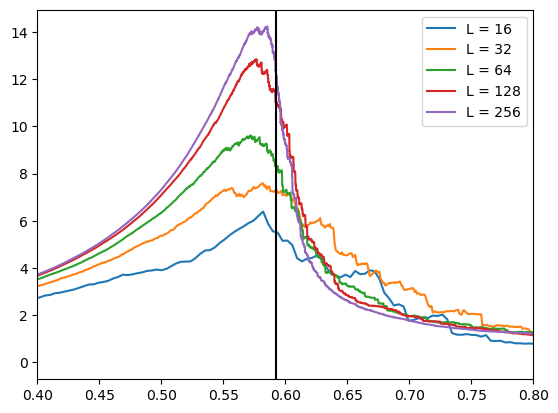

In [40]:
for idx, L in enumerate(sizes):
    nodes_added = np.arange(1, L**2 + 1)
    prob = nodes_added / L**2
    # plt.plot(prob, final["lcc"][idx] / nodes_added, label=f"L = {L}")
    plt.plot(prob, final["av_size"][idx], label=f"L = {L}")

plt.xlim(0.4, 0.8)
plt.axvline(0.59274605, c="k")
plt.legend()

In [42]:
g = ig.Graph.Lattice([500, 500], circular=False)
data = percolate(50, g, no_bar=False)

  0%|          | 0/50 [00:00<?, ?it/s]

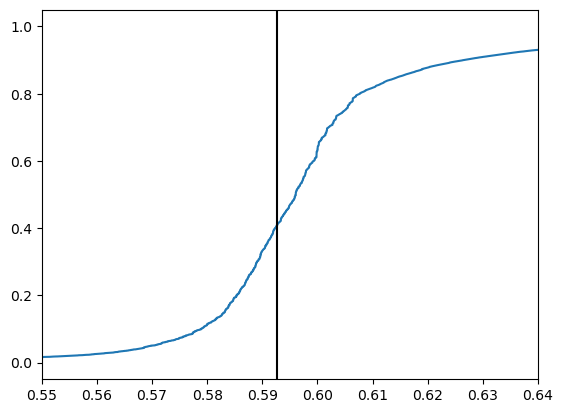

In [98]:
nodes_added = np.arange(1, g.vcount() + 1)
prob = nodes_added / g.vcount()

# plt.plot(prob, data["lcc"] / nodes_added)
# plt.plot(prob, data["av_size"])

plt.xlim(0.55, 0.64)
plt.axvline(0.59274605, c="k")

# Testing Cool Stuff, Improvements

In [8]:
from ipywidgets import IntSlider, interact, fixed


def plotter(frame, order, par, graph):
    colored = order[:frame+1]
    nodes = range(g.vcount())
    colors = ["cyan" if id in colored else "red" for id in nodes]
    fig, ax = plt.subplots(figsize=(10, 5))
    labels = [f"{n}\n{p}" for n, p in zip(nodes, par[frame])]
    ig.plot(
        graph,
        target=ax,
        layout="grid",
        vertex_size=0.8,
        vertex_color=colors,
        vertex_label=labels,
        vertex_label_size=10,
    )

In [9]:
g = ig.Graph.Lattice([500, 500], circular=False)
# ig.plot(
#     g,
#     layout="grid",
#     bbox=(500, 200),
#     vertex_size=10,
#     vertex_label=g.vs.indices,
#     vertex_label_dist=2,
#     vertex_label_angle=np.pi / 4,
# )

In [10]:
order = rng.permutation(g.vcount())
order

array([197766,  44475, 140961, ...,  39058, 152592, 148940])

In [18]:
np.iinfo(np.uint32)

iinfo(min=0, max=4294967295, dtype=uint32)

In [19]:
def find(ptr, i):
    while ptr[i] != -1:
        i = ptr[i]
    return i


def test_newman_ziff(graph, order, no_bar=False):
    neighbours = graph.get_adjlist()
    n = graph.vcount()
    data_parent = np.zeros((n, n), dtype="uint32")
    parent = np.full(n, -1, dtype="uint32")
    size = np.zeros(n, dtype="uint32")
    for idx in tqdm(range(n), disable=no_bar):
        root = order[idx]
        size[root] = 1
        for near in neighbours[root]:
            if size[near]:
                near = find(parent, near)
                if near != root:
                    if size[root] < size[near]:
                        size[near] += size[root]
                        parent[root] = near
                        root = near
                    else:
                        size[root] += size[near]
                        parent[near] = root
        data_parent[idx] = parent
    return data_parent

In [20]:
data = newman_ziff(g, order)

MemoryError: Unable to allocate 466. GiB for an array with shape (250000, 250000) and data type float64

In [21]:
par = test_newman_ziff(g, order)

MemoryError: Unable to allocate 233. GiB for an array with shape (250000, 250000) and data type uint32

In [83]:
interact(
    plotter,
    frame=IntSlider(0, 0, len(order) - 1),
    order=fixed(order),
    par=fixed(par),
    graph=fixed(g)
)

interactive(children=(IntSlider(value=0, description='frame', max=24), Output()), _dom_classes=('widget-intera…

<function __main__.plotter(frame, order, par, graph)>

In [90]:
def data(parents, order):
    size_distr = []
    for idx in range(len(order)):
        occupied = order[:idx+1]
        clusters = [find(parents[idx], node) for node in occupied]
        roots, counts = np.unique(clusters, return_counts=True)
        counts = np.sort(counts)
        size_distr.append(counts)
    return size_distr

In [87]:
n = 10
occupied = order[:n+1]
print(occupied)
np.unique([find(par[n], node) for node in occupied], return_counts=True)

[10 16  6  4  5 11  3 23  7 24 18]


(array([ 3,  5, 24], dtype=int64), array([2, 6, 3], dtype=int64))

In [92]:
data(par, order)

[array([1], dtype=int64),
 array([1, 1], dtype=int64),
 array([1, 1, 1], dtype=int64),
 array([1, 1, 1, 1], dtype=int64),
 array([1, 1, 3], dtype=int64),
 array([1, 5], dtype=int64),
 array([2, 5], dtype=int64),
 array([1, 2, 5], dtype=int64),
 array([1, 2, 6], dtype=int64),
 array([2, 2, 6], dtype=int64),
 array([2, 3, 6], dtype=int64),
 array([3, 9], dtype=int64),
 array([ 3, 10], dtype=int64),
 array([ 3, 11], dtype=int64),
 array([ 4, 11], dtype=int64),
 array([ 4, 12], dtype=int64),
 array([ 4, 13], dtype=int64),
 array([18], dtype=int64),
 array([19], dtype=int64),
 array([20], dtype=int64),
 array([ 1, 20], dtype=int64),
 array([22], dtype=int64),
 array([23], dtype=int64),
 array([24], dtype=int64),
 array([25], dtype=int64)]

# n clusters

In [49]:
# this worked before with the nan types

n_clusters = np.arange(1, g.vcount()+1) - np.sum(~np.isnan(par), axis=1)
print(n_clusters)
print(data["n_clusters"])

array([-24, -23, -22, -21, -20, -19, -18, -17, -16, -15, -14, -13, -12,
       -11, -10,  -9,  -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,   0])